<a href="https://www.kaggle.com/code/page0526/tcga-brca-survival-analysis?scriptVersionId=334581814" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/page0526/tcga-brca-survival-analysis?scriptVersionId=334535259" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Install necessary packages

In [5]:
!pip install lifelines timm==0.9.16

Wandb is a platform to track, visualize, and optimize AI models. Add wandb api key for experiment tracking. [Guide to get wandb api key](https://docs.wandb.ai/support/models/articles/how-do-i-find-my-api-key)

In [6]:
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("wandb_api_key")
wandb.login(key=wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

# 2. Data preparation

In [7]:
from pathlib import Path

embedding_dir = Path("/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC")

patient_to_slides = {}

for f in embedding_dir.glob("*.h5"):

    # TCGA-3C-AALI-01Z-00-DX1.xxx.h5
    slide_name = f.stem

    # first 3 fields
    patient = "-".join(slide_name.split("-")[:3])

    patient_to_slides.setdefault(patient, []).append(str(f))

In [8]:
len(patient_to_slides), patient_to_slides["TCGA-3C-AALI"]

(786,
 ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-3C-AALI-01Z-00-DX2.CF4496E0-AB52-4F3E-BDF5-C34833B91B7C.h5',
  '/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-3C-AALI-01Z-00-DX1.F6E9A5DF-D8FB-45CF-B4BD-C6B76294C291.h5'])

In [9]:
import pandas as pd
clinical = pd.read_csv("/kaggle/input/datasets/page0526/brca-uni/clinical.tsv", sep='\t', low_memory=False)

In [10]:
clinical.head()

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,27868bc3-23c8-5e85-a0e2-314e6cdf9b2a,Adjuvant,yes,Treatment Ongoing,'--,Hormone Therapy
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,aedf144c-6b7b-4d76-a3cb-4271aef10f1d,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76,'--,Adenomas and Adenocarcinomas,Diagnosis,'--,Breast,TCGA-A1-A0SB,...,'--,'--,'--,'--,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
4,TCGA-BRCA,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Informed Consent,19,'--,Adnexal and Skin Appendage Neoplasms,Diagnosis,No,Breast,TCGA-A2-A04W,...,'--,'--,'--,'--,024faa94-ec57-4d14-b919-62dcab409958,Adjuvant,yes,Treatment Ongoing,'--,Bisphosphonate Therapy


In [11]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hf_token")
wandb_key = user_secrets.get_secret("wandb_api_key")

In [12]:
import h5py
with h5py.File(patient_to_slides["TCGA-3C-AALI"][0],'r') as file:
    features = file['features'][:] # 1 x num_patches x 1536
    coords = file['coords'][:] # 1 x num_patches x 2
features.shape, features, coords.shape, coords

((1, 23676, 1536),
 array([[[-0.03030395,  0.08737233, -0.11065369, ..., -0.71261674,
          -0.1788493 ,  0.1267535 ],
         [-0.29914033, -0.10145787, -0.16805443, ..., -0.13661405,
           0.30127183, -0.07753039],
         [-0.0037378 ,  0.703131  , -0.29121646, ..., -0.29369664,
           0.03383807,  0.3137761 ],
         ...,
         [-0.46858543,  0.19168384, -0.5544701 , ..., -0.7270213 ,
           0.3446024 ,  0.15600972],
         [ 0.07971579,  0.21941309,  0.01054613, ..., -0.1877107 ,
           0.03886195, -0.14099303],
         [ 0.15664922,  0.1684319 , -0.09771799, ..., -0.3767476 ,
          -0.04932638, -0.02404776]]], dtype=float32),
 (1, 23676, 2),
 array([[[  3584,   8704],
         [  3584,   9216],
         [  4096,   6656],
         ...,
         [110080,  60928],
         [110080,  61440],
         [110080,  61952]]]))

In [13]:
patient_df = clinical.drop_duplicates(subset="cases.submitter_id").copy()

In [14]:
import numpy as np

patient_df["event"] = (
    patient_df["demographic.vital_status"]
    .eq("Dead")
    .astype(int)
)

patient_df["time"] = np.where(
    patient_df["event"] == 1,
    patient_df["demographic.days_to_death"],
    patient_df["diagnoses.days_to_last_follow_up"]
)

In [15]:
label_lookup = (
    patient_df
    .set_index("cases.submitter_id")[["time", "event"]]
    .to_dict("index")
)

In [16]:
dataset = []

for patient_id, slide_paths in patient_to_slides.items():

    if patient_id not in label_lookup:
        continue

    label = label_lookup[patient_id]

    try:
        time = float(label["time"])
    except (ValueError, TypeError):
        continue

    event = int(label["event"])

    dataset.append({
        "patient_id": patient_id,
        "slides": slide_paths,
        "time": time,
        "event": event,
    })

In [17]:
len(dataset), dataset[0]

(748,
 {'patient_id': 'TCGA-A1-A0SM',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-A1-A0SM-01Z-00-DX1.AD503DBD-4D93-4476-B467-F091254FDF78.h5'],
  'time': 242.0,
  'event': 0})

In [18]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=[d["event"] for d in dataset]
)

In [19]:
import torch
from torch.utils.data import Dataset

class SurvivalDataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        feats = []

        for slide in sample["slides"]:

            with h5py.File(slide, "r") as f:
                x = torch.from_numpy(
                    f["features"][0]        # (num_patches,1536)
                ).float()

            feats.append(x)

        feats = torch.cat(feats, dim=0)

        return {
            "features": feats,
            "time": torch.tensor(sample["time"], dtype=torch.float32),
            "event": torch.tensor(sample["event"], dtype=torch.float32),
        }

In [20]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    feats = [b["features"] for b in batch]

    lengths = torch.tensor(
        [len(f) for f in feats]
    )

    padded = pad_sequence(
        feats,
        batch_first=True
    )

    max_len = padded.size(1)

    mask = (
        torch.arange(max_len)[None]
        < lengths[:,None]
    )

    return {

        "features": padded,

        "mask": mask,

        "time": torch.stack(
            [b["time"] for b in batch]
        ),

        "event": torch.stack(
            [b["event"] for b in batch]
        )
    }

In [21]:
EPOCHS = 50
BS = 4

In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    SurvivalDataset(train_data),
    batch_size=BS,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    SurvivalDataset(val_data),
    batch_size=BS,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

# 3. Model Architecture

In [23]:
import torch.nn as nn

class GatedAttention(nn.Module):

    def __init__(self,
                 in_dim=1536,
                 hidden=256):

        super().__init__()

        self.V = nn.Linear(in_dim, hidden)

        self.U = nn.Linear(in_dim, hidden)

        self.w = nn.Linear(hidden,1)

    def forward(self,x,mask):

        A_v = torch.tanh(
            self.V(x)
        )

        A_u = torch.sigmoid(
            self.U(x)
        )

        A = self.w(
            A_v*A_u
        ).squeeze(-1)

        A[~mask] = -1e9

        A = torch.softmax(A,dim=1)

        M = torch.bmm(
            A.unsqueeze(1),
            x
        ).squeeze(1)

        return M,A

In [24]:
class SurvivalMIL(nn.Module):

    def __init__(self):

        super().__init__()

        self.attention = GatedAttention()

        self.head = nn.Sequential(

            nn.Linear(1536,256),

            nn.ReLU(),

            nn.Dropout(0.25),

            nn.Linear(256,1)
        )

    def forward(self,x,mask):

        patient_embedding,attn = self.attention(
            x,
            mask
        )

        risk = self.head(
            patient_embedding
        ).squeeze(-1)

        return risk,attn

In [25]:
def cox_loss(risk,time,event):

    order = torch.argsort(
        time,
        descending=True
    )

    risk = risk[order]

    event = event[order]

    log_cumsum = torch.logcumsumexp(
        risk,
        dim=0
    )

    loss = -(risk-log_cumsum)*event

    return loss.sum()/event.sum().clamp(min=1)

In [26]:
device = "cuda"

model = SurvivalMIL()

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)

model = model.cuda()
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

Using 2 GPUs


# 4. Training

In [27]:
best_val_cindex = -1.0
run = wandb.init(
    project="brca-survival",
    name="abmil-uni2",
    config={
        "epochs": EPOCHS,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "feature_dim": 1536,
        "model": "AttentionMIL",
    },
)

In [28]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

In [29]:
from tqdm import tqdm
from lifelines.utils import concordance_index
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

for epoch in range(EPOCHS):

    ########################
    # Train
    ########################
    model.train()

    train_losses = []
    train_risks = []
    train_times = []
    train_events = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:

        x = batch["features"].to(device, non_blocking=True)
        mask = batch["mask"].to(device, non_blocking=True)
        t = batch["time"].to(device, non_blocking=True)
        e = batch["event"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward pass
        with autocast(device_type="cuda"):
            risk, _ = model(x, mask)
            loss = cox_loss(risk, t, e)

        # Mixed precision backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())

        train_risks.extend(risk.detach().float().cpu().numpy())
        train_times.extend(t.cpu().numpy())
        train_events.extend(e.cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = np.mean(train_losses)

    train_cindex = concordance_index(
        np.array(train_times),
        -np.array(train_risks),
        np.array(train_events)
    )

    ########################
    # Validation
    ########################
    model.eval()

    val_losses = []
    val_risks = []
    val_times = []
    val_events = []

    with torch.no_grad():

        for batch in val_loader:

            x = batch["features"].to(device, non_blocking=True)
            mask = batch["mask"].to(device, non_blocking=True)
            t = batch["time"].to(device, non_blocking=True)
            e = batch["event"].to(device, non_blocking=True)

            with autocast(device_type="cuda"):
                risk, _ = model(x, mask)
                loss = cox_loss(risk, t, e)

            val_losses.append(loss.item())

            val_risks.extend(risk.float().cpu().numpy())
            val_times.extend(t.cpu().numpy())
            val_events.extend(e.cpu().numpy())

    val_loss = np.mean(val_losses)

    val_cindex = concordance_index(
        np.array(val_times),
        -np.array(val_risks),
        np.array(val_events)
    )

    ########################
    # Save checkpoint
    ########################

    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),  # Save AMP state
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_cindex": train_cindex,
        "val_cindex": val_cindex,
    }

    torch.save(checkpoint, "last.pt")

    if val_cindex > best_val_cindex:
        best_val_cindex = val_cindex
        torch.save(checkpoint, "best.pt")

    ########################
    # Log to W&B
    ########################

    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/cindex": train_cindex,
        "val/loss": val_loss,
        "val/cindex": val_cindex,
        "best_val_cindex": best_val_cindex,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train C-index {train_cindex:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val C-index {val_cindex:.4f}"
    )

Epoch 1/50: 100%|██████████| 150/150 [02:03<00:00,  1.21it/s, loss=0.6538]


Epoch 001 | Train Loss 0.2902 | Train C-index 0.5835 | Val Loss 0.1710 | Val C-index 0.6002


Epoch 2/50: 100%|██████████| 150/150 [02:02<00:00,  1.23it/s, loss=0.0000]


Epoch 002 | Train Loss 0.2837 | Train C-index 0.7072 | Val Loss 0.1673 | Val C-index 0.6685


Epoch 3/50: 100%|██████████| 150/150 [02:01<00:00,  1.24it/s, loss=0.0000]


...

Epoch 048 | Train Loss 0.0339 | Train C-index 0.9724 | Val Loss 0.3747 | Val C-index 0.5956


Epoch 49/50: 100%|██████████| 150/150 [02:05<00:00,  1.19it/s, loss=0.0000]


Epoch 049 | Train Loss 0.0081 | Train C-index 0.9680 | Val Loss 0.3918 | Val C-index 0.5836


Epoch 50/50: 100%|██████████| 150/150 [02:02<00:00,  1.23it/s, loss=0.0000]


Epoch 050 | Train Loss 0.0394 | Train C-index 0.9688 | Val Loss 0.3385 | Val C-index 0.6445


In [30]:
model_to_save = model.module if hasattr(model, "module") else model

checkpoint = {
    "epoch": epoch + 1,
    "model_state_dict": model_to_save.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_loss,
    "val_loss": val_loss,
    "train_cindex": train_cindex,
    "val_cindex": val_cindex,
}
torch.save(checkpoint, "last.pt")

if val_cindex > best_val_cindex:
    best_val_cindex = val_cindex
    torch.save(checkpoint, "best.pt")

In [31]:
artifact = wandb.Artifact(
    name=f"{run.name}-checkpoints",
    type="model",
    metadata={
        "architecture": "AttentionMIL",
        "feature_dim": 1536,
        "best_val_cindex": float(best_val_cindex),
    }
)

artifact.add_file("last.pt")
artifact.add_file("best.pt")

run.log_artifact(artifact)

wandb.finish()

best_val_cindex,▁▅▅▅▅▅▆█████████████████████████████████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/cindex,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇████▇██████████████████
train/loss,██▆▆▅▄▄▄▃▂▂▃▃▂▂▃▃▂▁▂▁▂▂▂▂▁▁▁▂▁▂▂▂▁▁▁▁▁▁▂
val/cindex,▂▅▄▂▂▄▆█▄▅▃▇▄▆▆▅▄▃▃▇▇▅▄▅▅▅▃▃▄▅▄▁▁▄▅▄▃▂▁▄
val/loss,▁▁▃▃▃▃▄▂▃▃▄▁▃▂▂▃▅▆▆▄▄▅▅▅▅▅▆▇▅▅▅█▇▆▆▄▆▆▅▅
best_val_cindex,0.71745
epoch,50
learning_rate,0.0001
train/cindex,0.96875


# 5. Evaluation and Visualization

In [32]:
model.eval()

times = []
events = []
risks = []

with torch.no_grad():

    for batch in val_loader:

        x = batch["features"].cuda()

        mask = batch["mask"].cuda()

        risk,_ = model(x,mask)

        risks.extend(
            risk.cpu().numpy()
        )

        times.extend(
            batch["time"].numpy()
        )

        events.extend(
            batch["event"].numpy()
        )

cindex = concordance_index(
    times,
    -torch.tensor(risks).numpy(),
    events
)

print(cindex)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


0.644506001846722


In [33]:
sample = next(iter(train_loader))
print(sample['features'].shape, sample['mask'].shape)

torch.Size([4, 18610, 1536]) torch.Size([4, 18610])


In [34]:
val_data[:10]

[{'patient_id': 'TCGA-E2-A15F',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-E2-A15F-01Z-00-DX1.F022214A-3F0C-4DA4-A0EE-735D27480A45.h5'],
  'time': 658.0,
  'event': 0},
 {'patient_id': 'TCGA-AR-A1AV',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-AR-A1AV-01Z-00-DX1.93698893-7C5C-44C1-A488-ED358D523693.h5'],
  'time': 1864.0,
  'event': 0},
 {'patient_id': 'TCGA-LL-A5YP',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-LL-A5YP-01Z-00-DX1.ADA978DF-6625-4C4D-AE0C-F589B2BA4897.h5'],
  'time': 450.0,
  'event': 0},
 {'patient_id': 'TCGA-A2-A0EM',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-A2-A0EM-01Z-00-DX1.305CF011-7451-4880-9A5D-AB4432CF53A5.h5'],
  'time': 3094.0,
  'event': 0},
 {'patient_id': 'TCGA-BH-A0DS',
  'slides': ['/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-BH-A0DS-01Z-00-DX1.38E82A1F-21B9-4B97-A304-15B886EA68A0.h5'],
  'time': 78.0,
  'event': 0},

In [36]:
ckpt = torch.load(
    "/kaggle/working/best.pt",
    map_location="cpu",
    weights_only=False,
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

DataParallel(
  (module): SurvivalMIL(
    (attention): GatedAttention(
      (V): Linear(in_features=1536, out_features=256, bias=True)
      (U): Linear(in_features=1536, out_features=256, bias=True)
      (w): Linear(in_features=256, out_features=1, bias=True)
    )
    (head): Sequential(
      (0): Linear(in_features=1536, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.25, inplace=False)
      (3): Linear(in_features=256, out_features=1, bias=True)
    )
  )
)

(18148, 1536)
(18148, 2)
Risk: -1.1833
Attention sum: 1.000000


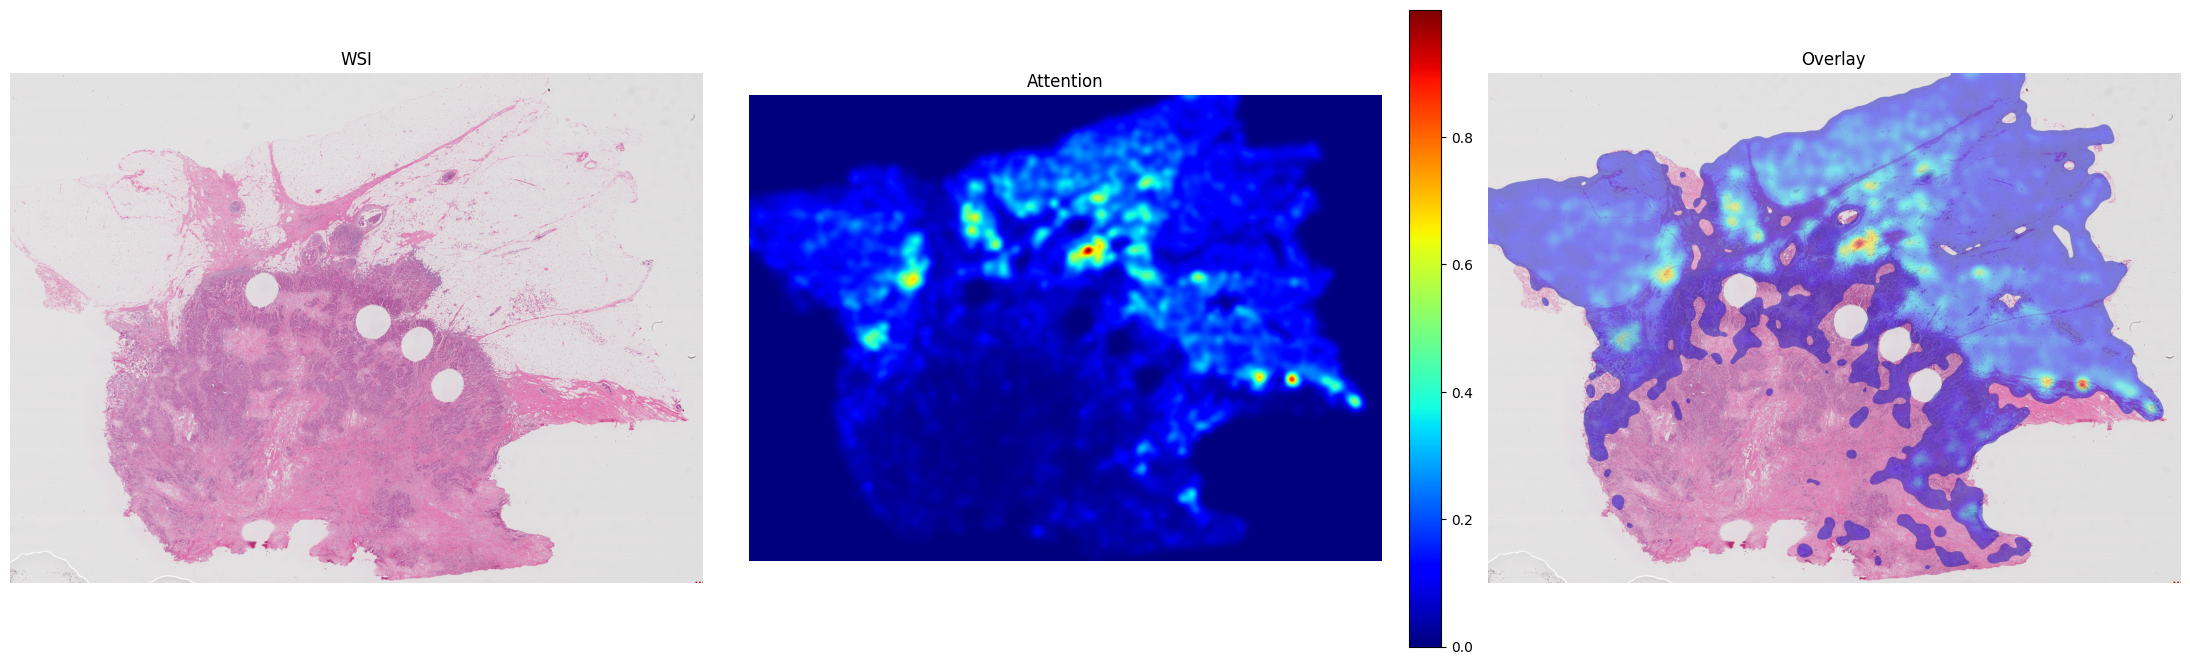

In [37]:
import cv2
import openslide
import matplotlib.pyplot as plt

# =====================================================
# Load features
# =====================================================

h5_path = "/kaggle/input/datasets/page0526/brca-uni/TCGA-BRCA_IDC/TCGA-3C-AALI-01Z-00-DX1.F6E9A5DF-D8FB-45CF-B4BD-C6B76294C291.h5"
wsi_path = "/kaggle/input/datasets/page0526/brca-uni/wsi/data/TCGA-3C-AALI-01Z-00-DX1/TCGA-3C-AALI-01Z-00-DX1.F6E9A5DF-D8FB-45CF-B4BD-C6B76294C291.svs"

with h5py.File(h5_path, "r") as f:
    features = f["features"][:].squeeze(0)
    coords = f["coords"][:].squeeze(0)

print(features.shape)
print(coords.shape)

# =====================================================
# Inference
# =====================================================

device = "cuda"

feats = torch.from_numpy(features).float().unsqueeze(0).to(device)

mask = torch.ones(
    (1, feats.shape[1]),
    dtype=torch.bool,
    device=device,
)

net = model.module if isinstance(model, torch.nn.DataParallel) else model
net.eval()

with torch.no_grad():
    risk, attention = net(feats, mask)

attention = attention.squeeze(0).cpu().numpy()

print(f"Risk: {risk.item():.4f}")
print(f"Attention sum: {attention.sum():.6f}")

# =====================================================
# Normalize for visualization ONLY
# =====================================================

att_vis = attention.copy()

att_vis -= att_vis.min()
att_vis /= (att_vis.max() + 1e-8)

# =====================================================
# Open WSI
# =====================================================

slide = openslide.OpenSlide(wsi_path)

thumb_size = 2048

thumbnail = np.array(
    slide.get_thumbnail((thumb_size, thumb_size))
)

thumb_h, thumb_w = thumbnail.shape[:2]

w0, h0 = slide.dimensions

sx = thumb_w / w0
sy = thumb_h / h0

# =====================================================
# Heatmap accumulation
# =====================================================

heatmap = np.zeros((thumb_h, thumb_w), dtype=np.float32)
counter = np.zeros((thumb_h, thumb_w), dtype=np.float32)

patch_size = 224

patch_w = max(1, round(patch_size * sx))
patch_h = max(1, round(patch_size * sy))

for (x, y), score in zip(coords, att_vis):

    xx = int(x * sx)
    yy = int(y * sy)

    x2 = min(xx + patch_w, thumb_w)
    y2 = min(yy + patch_h, thumb_h)

    heatmap[yy:y2, xx:x2] += score
    counter[yy:y2, xx:x2] += 1

counter[counter == 0] = 1

heatmap /= counter

# =====================================================
# Smooth
# =====================================================

heatmap = cv2.GaussianBlur(
    heatmap,
    (0, 0),
    sigmaX=12,
)

heatmap /= (heatmap.max() + 1e-8)

# =====================================================
# Color map
# =====================================================

heat_uint8 = np.uint8(255 * heatmap)

colored = cv2.applyColorMap(
    heat_uint8,
    cv2.COLORMAP_JET,
)

colored = cv2.cvtColor(
    colored,
    cv2.COLOR_BGR2RGB,
)

# =====================================================
# Overlay only on attended regions
# =====================================================

overlay = thumbnail.copy()

mask_overlay = heatmap > 0.05

overlay[mask_overlay] = (
    0.55 * thumbnail[mask_overlay]
    + 0.45 * colored[mask_overlay]
).astype(np.uint8)

# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(22, 8),
)

ax[0].imshow(thumbnail)
ax[0].set_title("WSI")
ax[0].axis("off")

im = ax[1].imshow(
    heatmap,
    cmap="jet",
)

ax[1].set_title("Attention")
ax[1].axis("off")

plt.colorbar(
    im,
    ax=ax[1],
    fraction=0.046,
    pad=0.04,
)

ax[2].imshow(overlay)
ax[2].set_title("Overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()